In [4]:
from time_series_gan.TimeGAN import TimeGAN
import numpy as np
import pandas as pd
from time_series_gan.metrics import dWasserstein, dFrechet, ONND, score
from Optimisation_MH import generer_resultats, Metropolis_Hasting
import torch.nn as nn

In [5]:
data = pd.read_csv("data/synthetic_data.csv")
model = TimeGAN()
model.set_data(data)
len(model.val_data)

980

In [ ]:
# archi = {'generator': {'architecture': 'MLP', 'layer_sizes': [256, 256, 128], 'activation': 'ReLU'}, 'discriminator': {'architecture': 'MLP', 'layer_sizes': [256, 256, 128, 1], 'activation': nn.Sigmoid()}}
archi = Metropolis_Hasting(0.1, data, TimeGAN, ite = 100, metrique=score, nom_de_la_métrique = "score")

fit took 428.529464 seconds
MH étape : 0
suppression d'une couche du discriminator
fit took 402.838000 seconds
echec


MH étape : 1
ajout d'une couche au discriminator
fit took 397.262808 seconds
echec


MH étape : 2
modification des paramètres
fit took 373.825422 seconds
succes
6.457386123650512 ->  4.657462320151616

{'lr_g': 0.002017, 'lr_d': 0.002491, 'lr_e': 0.000517, 'lr_r': 0.001091, 'epochs': 67, 'batch_size': 40, 'latent_dim': 17, 'hidden_dim': 15, 'seq_length': 10, 'n_critic': 2}
generator : [15]        ReLU
discriminator : [1]        ReLU


MH étape : 3
ajout d'une couche au generator
fit took 386.863919 seconds
echec


MH étape : 4
modification des paramètres
fit took 380.905890 seconds
echec


MH étape : 5
ajout d'une couche au generator
fit took 351.034756 seconds
echec


MH étape : 6
modification des paramètres
fit took 409.572364 seconds
echec


MH étape : 7
suppression d'une couche du generator
fit took 387.512614 seconds
echec


MH étape : 8
modification des paramètre

Epoch [1/23] Loss AE: 0.0163, Loss D: 1.3815, Loss G: 0.6982, 
Epoch [2/23] Loss AE: 0.0131, Loss D: 1.4225, Loss G: 0.6593, 
Epoch [3/23] Loss AE: 0.0158, Loss D: 1.3812, Loss G: 0.7080, 
Epoch [4/23] Loss AE: 0.0080, Loss D: 1.3394, Loss G: 0.7021, 
Epoch [5/23] Loss AE: 0.0389, Loss D: 1.4078, Loss G: 0.7354, 
Epoch [6/23] Loss AE: 0.0056, Loss D: 1.3234, Loss G: 0.7329, 
Epoch [7/23] Loss AE: 0.0049, Loss D: 1.3600, Loss G: 0.6792, 
Epoch [8/23] Loss AE: 0.0045, Loss D: 1.3739, Loss G: 0.7017, 
Epoch [9/23] Loss AE: 0.0059, Loss D: 1.4055, Loss G: 0.7126, 
Epoch [10/23] Loss AE: 0.0049, Loss D: 1.3426, Loss G: 0.7720, 
Epoch [11/23] Loss AE: 0.0083, Loss D: 1.4086, Loss G: 0.7067, 
Epoch [12/23] Loss AE: 0.0050, Loss D: 1.4076, Loss G: 0.6596, 
Epoch [13/23] Loss AE: 0.0043, Loss D: 1.3741, Loss G: 0.6931, 
Epoch [14/23] Loss AE: 0.0048, Loss D: 1.3771, Loss G: 0.7107, 
Epoch [15/23] Loss AE: 0.0054, Loss D: 1.3902, Loss G: 0.6950, 
Epoch [16/23] Loss AE: 0.0041, Loss D: 1.3639, Lo

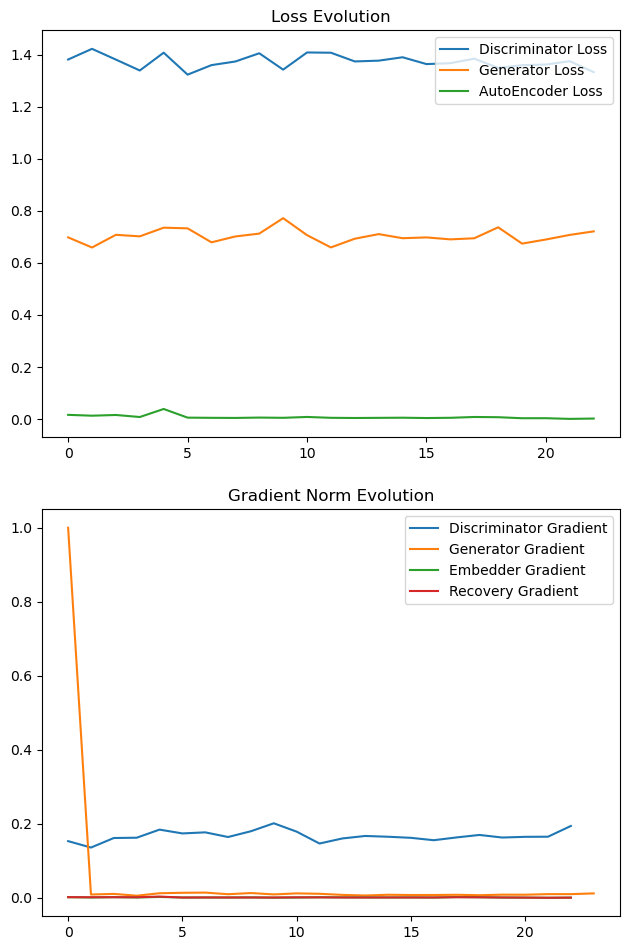

Autoencoder Reconstruction Loss: 0.0024


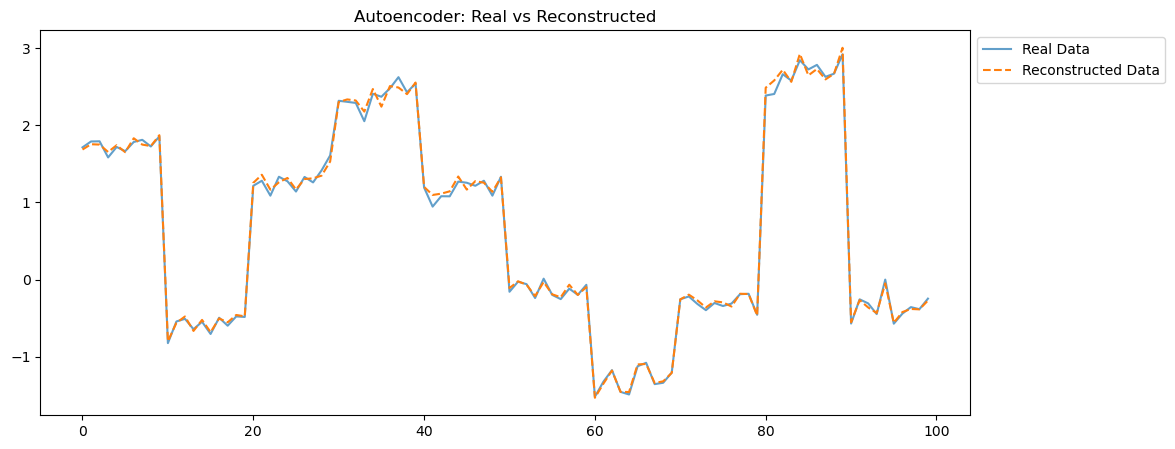

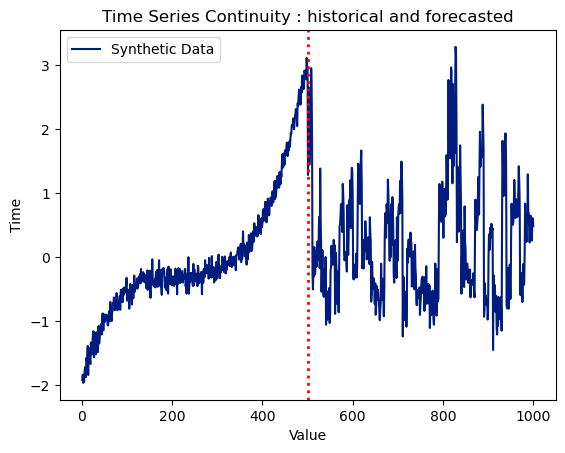

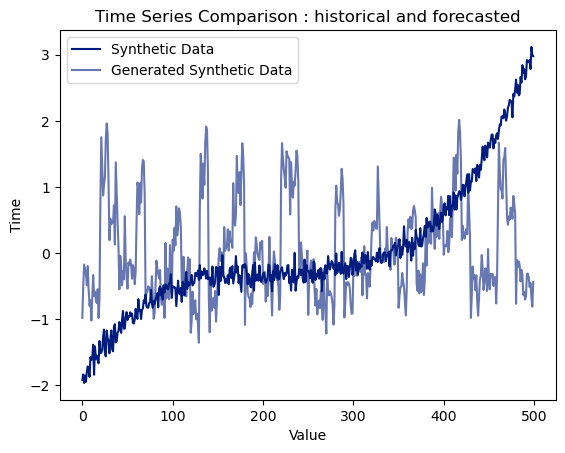

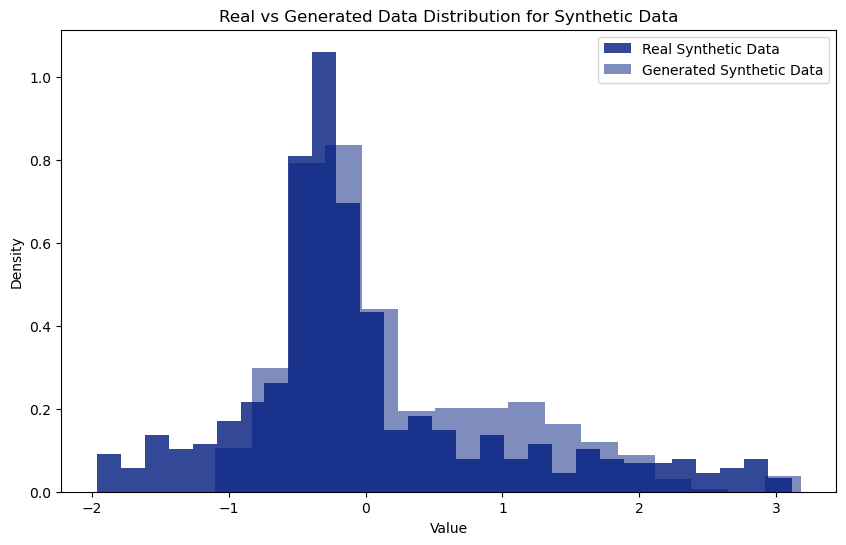

fit took 25.759336 seconds


{}

In [6]:
params = {'lr_g': 0.00164, 'lr_d': 0.001969, 'lr_e': 0.0002164, 'lr_r': 0.0006666, 'epochs': 23, 'batch_size': 14, 'latent_dim': 19, 'hidden_dim': 15, 'seq_length': 10, 'n_critic': 1}
archi = {'generator': {'architecture': 'MLP', 'layer_sizes': [25, 15], 'activation': 'ReLU'}, 'discriminator': {'architecture': 'MLP', 'layer_sizes': [14, 1], 'activation': 'ReLU'}}

model = TimeGAN()
model.set_data(data)
model.fit(architectures = archi, params = params, verbose = True)

In [7]:
n = 20

w = np.array([model.compute_val_metric(dWasserstein, {}) for _ in range(n)])
print("Wasserstein", w.mean(), w.std())

f = np.array([model.compute_val_metric(dFrechet, {}) for _ in range(n)])
print("Fréchet", f.mean(), f.std())

o = np.array([model.compute_val_metric(ONND, {}) for _ in range(n)])
print("ONND", o.mean(), o.std())

s = np.array([model.compute_val_metric(score, {}) for _ in range(n)])
print("Score", s.mean(), s.std())

Wasserstein 0.24585921639984 0.03061190783607831
Fréchet 2.052620461418173 0.47164868534757015
ONND 0.011154421225043506 0.006294396864676476
Score 3.908483569571684 0.4860760700544844


In [24]:
print("Wasserstein", model.compute_val_metric(dWasserstein, {}))
print("Fréchet", model.compute_val_metric(dFrechet, {}))
print("ONND", model.compute_val_metric(ONND, {}))
print("Score", model.compute_val_metric(score, {}))

Wasserstein 0.19499098884548213
Fréchet 1.5911748473341079
ONND 0.007786213754181009
Score 4.067793512248592


In [4]:
model.fit_hyperparameters({"lr_g": [5e-6, 5e-3], "lr_d": [5e-6, 5e-3],"lr_e": [5e-6, 5e-3], "lr_r": [5e-6, 5e-3], "epochs": [50, 150], "batch_size": [8,300], "latent_dim": [1,150], "hidden_dim" : [20, 250], "seq_length" : [6, 70], "n_critic" : [1,5]}, n_trials = 30)

[I 2025-04-22 11:59:03,658] A new study created in memory with name: no-name-174e215c-3bca-4d25-a1b3-66eb448ad573


fit took 4.938790 seconds


[I 2025-04-22 12:01:13,426] Trial 0 finished with value: 10.945153177764325 and parameters: {'lr_g': 0.0017940728868586343, 'lr_d': 0.0015174732798052715, 'lr_e': 0.0018083979111378826, 'lr_r': 0.00345777181231307, 'epochs': 68, 'batch_size': 202, 'latent_dim': 31, 'hidden_dim': 21, 'seq_length': 20, 'n_critic': 2}. Best is trial 0 with value: 10.945153177764325.


fit took 15.340742 seconds


[I 2025-04-22 12:04:16,192] Trial 1 finished with value: 38.53994428105541 and parameters: {'lr_g': 0.004933416663434902, 'lr_d': 0.0022273324864617795, 'lr_e': 0.0007738405371407677, 'lr_r': 0.0029813938976070696, 'epochs': 101, 'batch_size': 177, 'latent_dim': 48, 'hidden_dim': 99, 'seq_length': 36, 'n_critic': 4}. Best is trial 0 with value: 10.945153177764325.


...

[I 2025-04-22 14:28:01,415] Trial 27 finished with value: 9.248491620118518 and parameters: {'lr_g': 0.00148475361393105, 'lr_d': 0.004271718701727808, 'lr_e': 0.0044465035487562, 'lr_r': 0.0007346704364508104, 'epochs': 90, 'batch_size': 100, 'latent_dim': 57, 'hidden_dim': 182, 'seq_length': 44, 'n_critic': 1}. Best is trial 10 with value: 3.200340815914982.


fit took 38.608206 seconds


[I 2025-04-22 14:34:36,233] Trial 28 finished with value: 8.482301403831286 and parameters: {'lr_g': 0.00033495456773192066, 'lr_d': 0.003707518922580498, 'lr_e': 0.004962110851908003, 'lr_r': 0.0015764150980751399, 'epochs': 74, 'batch_size': 29, 'latent_dim': 17, 'hidden_dim': 217, 'seq_length': 51, 'n_critic': 2}. Best is trial 10 with value: 3.200340815914982.


fit took 10.826028 seconds


[I 2025-04-22 14:36:14,632] Trial 29 finished with value: 5.917729249601262 and parameters: {'lr_g': 0.001965302829151525, 'lr_d': 0.0029140064208893718, 'lr_e': 0.0021223720078543834, 'lr_r': 0.0021797649518921795, 'epochs': 60, 'batch_size': 191, 'latent_dim': 31, 'hidden_dim': 189, 'seq_length': 24, 'n_critic': 4}. Best is trial 10 with value: 3.200340815914982.


In [19]:
print(model.parameters)

{'lr_g': 0.00017104234579088046, 'lr_d': 0.004951768389891787, 'lr_e': 0.004888414819927105, 'lr_r': 0.00031371446865759763, 'epochs': 132, 'batch_size': 20, 'latent_dim': 55, 'hidden_dim': 163, 'seq_length': 53, 'n_critic': 1}


In [17]:
model.fit(verbose = True, params = model.parameters)

Epoch [1/132] Loss AE: 0.2402, Loss D: 0.1729, Loss G: 17.3355, 
Epoch [2/132] Loss AE: 0.1309, Loss D: 0.0000, Loss G: 18.4207, 
Epoch [3/132] Loss AE: 0.1058, Loss D: 0.0000, Loss G: 18.4207, 
Epoch [4/132] Loss AE: 0.0763, Loss D: 0.0000, Loss G: 18.4207, 


KeyboardInterrupt: 

In [8]:
print("Wasserstein", model.compute_val_metric(dWasserstein, {}))
print("Fréchet", model.compute_val_metric(dFrechet, {}))
print("ONND", model.compute_val_metric(ONND, {}))
print("Score", model.compute_val_metric(score, {}))

Wasserstein 0.6925781375445813


KeyboardInterrupt: 